In [ ]:
import pandas as pd
import random
from datetime import datetime, timedelta

dados = []

inicio = datetime(2026, 1, 1)
peso_atual = 1000

for i in range(30):  # 30 dias
    dia = inicio + timedelta(days=i)

    for hora in [8, 12, 18, 22]:

        temperatura = random.randint(22, 33)

        # definição do período
        if hora < 12:
            periodo = "Manha"
            consumo = random.randint(50, 90)

        elif hora < 18:
            periodo = "Tarde"
            consumo = random.randint(90, 140)

        else:
            periodo = "Noite"
            consumo = random.randint(120, 180)

        # finais de semana aumentam consumo
        if dia.weekday() >= 5:
            consumo += random.randint(10, 30)

        # temperatura influencia
        if temperatura > 29:
            consumo += random.randint(5, 20)

        peso_inicial = peso_atual
        peso_final = max(0, peso_inicial - consumo)

        reabastecimento = 0

        # reabastece automaticamente
        if peso_final < 150:
            reabastecimento = 1
            peso_atual = 1000
        else:
            peso_atual = peso_final

        dados.append([
            dia.date(),
            hora,
            temperatura,
            dia.strftime("%A"),
            periodo,
            peso_inicial,
            consumo,
            peso_final,
            reabastecimento
        ])

colunas = [
    "data",
    "hora",
    "temperatura_c",
    "dia_semana",
    "periodo",
    "peso_inicial_g",
    "consumo_g",
    "peso_final_g",
    "reabastecimento"
]

df = pd.DataFrame(dados, columns=colunas)

df.head()

,data,hora,temperatura_c,dia_semana,periodo,peso_inicial_g,consumo_g,peso_final_g,reabastecimento
0,2026-01-01,8,23,Thursday,Manha,1000,86,914,0
1,2026-01-01,12,22,Thursday,Tarde,914,113,801,0
2,2026-01-01,18,33,Thursday,Noite,801,171,630,0
3,2026-01-01,22,31,Thursday,Noite,630,140,490,0
4,2026-01-02,8,26,Friday,Manha,490,90,400,0


In [ ]:
# Visualizando as primeiras linhas do dataset original
df.head()

,data,hora,temperatura_c,dia_semana,periodo,peso_inicial_g,consumo_g,peso_final_g,reabastecimento
0,2026-01-01,8,23,Thursday,Manha,1000,86,914,0
1,2026-01-01,12,22,Thursday,Tarde,914,113,801,0
2,2026-01-01,18,33,Thursday,Noite,801,171,630,0
3,2026-01-01,22,31,Thursday,Noite,630,140,490,0
4,2026-01-02,8,26,Friday,Manha,490,90,400,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   data             120 non-null    object
 1   hora             120 non-null    int64 
 2   temperatura_c    120 non-null    int64 
 3   dia_semana       120 non-null    object
 4   periodo          120 non-null    object
 5   peso_inicial_g   120 non-null    int64 
 6   consumo_g        120 non-null    int64 
 7   peso_final_g     120 non-null    int64 
 8   reabastecimento  120 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 8.6+ KB


In [ ]:
df.describe()

,hora,temperatura_c,peso_inicial_g,consumo_g,peso_final_g,reabastecimento
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,15.000000,27.391667,612.691667,130.875000,482.016667,0.133333
std,5.407744,3.200042,266.067559,37.327207,272.083094,0.341360
min,8.000000,22.000000,157.000000,54.000000,0.000000,0.000000
25%,11.000000,25.000000,393.000000,98.750000,266.000000,0.000000
50%,15.000000,27.000000,631.000000,136.500000,486.500000,0.000000
75%,19.000000,30.000000,837.750000,160.250000,729.500000,0.000000
max,22.000000,33.000000,1000.000000,214.000000,927.000000,1.000000


In [ ]:
#verificar se há valores ausentes

df.isnull().sum()

,0
data,0
hora,0
temperatura_c,0
dia_semana,0
periodo,0
peso_inicial_g,0
consumo_g,0
peso_final_g,0
reabastecimento,0


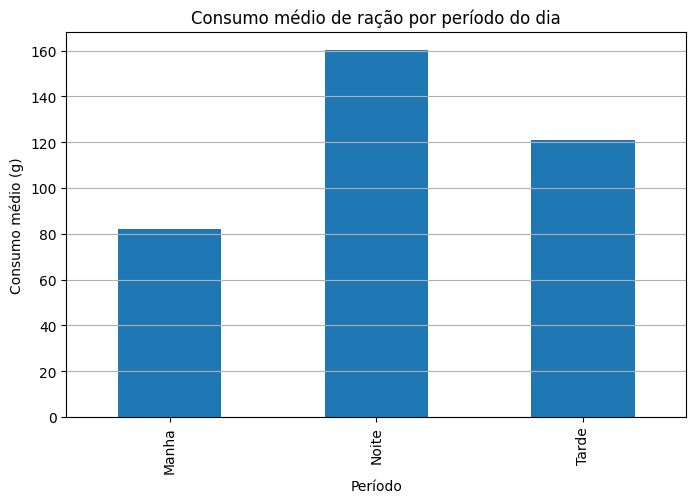

In [ ]:
# Consumo médio por período do dia
import matplotlib.pyplot as plt

consumo_periodo = df.groupby("periodo")["consumo_g"].mean()

plt.figure(figsize=(8,5))
consumo_periodo.plot(kind="bar")
plt.title("Consumo médio de ração por período do dia")
plt.xlabel("Período")
plt.ylabel("Consumo médio (g)")
plt.grid(axis="y")
plt.show()

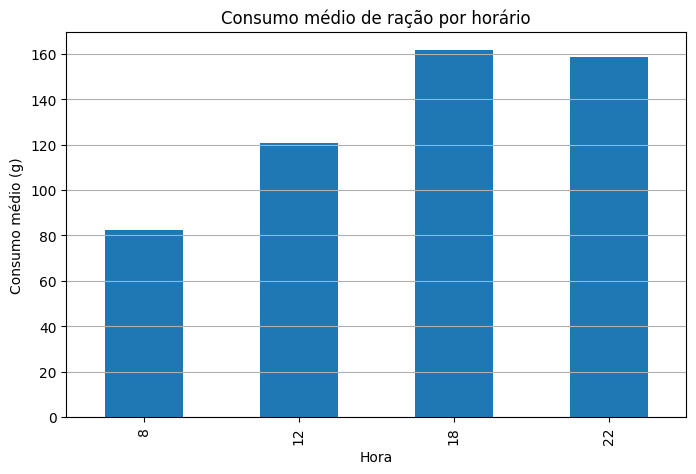

In [ ]:
# Consumo médio por horário
consumo_hora = df.groupby("hora")["consumo_g"].mean()

plt.figure(figsize=(8,5))
consumo_hora.plot(kind="bar")
plt.title("Consumo médio de ração por horário")
plt.xlabel("Hora")
plt.ylabel("Consumo médio (g)")
plt.grid(axis="y")
plt.show()

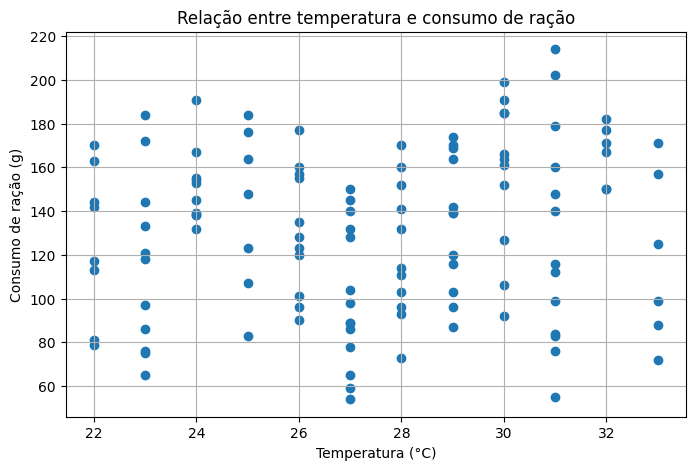

In [ ]:
# Relação entre temperatura e consumo
plt.figure(figsize=(8,5))
plt.scatter(df["temperatura_c"], df["consumo_g"])
plt.title("Relação entre temperatura e consumo de ração")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Consumo de ração (g)")
plt.grid(True)
plt.show()

In [ ]:
# Transformando variáveis categóricas em números
df_ml = pd.get_dummies(df, columns=['periodo', 'dia_semana'])

df_ml.head()

,data,hora,temperatura_c,peso_inicial_g,consumo_g,peso_final_g,reabastecimento,periodo_Manha,periodo_Noite,periodo_Tarde,dia_semana_Friday,dia_semana_Monday,dia_semana_Saturday,dia_semana_Sunday,dia_semana_Thursday,dia_semana_Tuesday,dia_semana_Wednesday
0,2026-01-01,8,23,1000,86,914,0,True,False,False,False,False,False,False,True,False,False
1,2026-01-01,12,22,914,113,801,0,False,False,True,False,False,False,False,True,False,False
2,2026-01-01,18,33,801,171,630,0,False,True,False,False,False,False,False,True,False,False
3,2026-01-01,22,31,630,140,490,0,False,True,False,False,False,False,False,True,False,False
4,2026-01-02,8,26,490,90,400,0,True,False,False,True,False,False,False,False,False,False


In [ ]:
# Variáveis de entrada
X = df_ml.drop(columns=['data', 'consumo_g', 'peso_final_g', 'reabastecimento'])

# Variável alvo
y = df_ml['consumo_g']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)

LinearRegression()

In [ ]:
previsoes = modelo.predict(X_test)

previsoes[:5]

array([ 79.53078531, 154.67258953,  72.90044166, 150.56968733,
       150.44250598])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, previsoes)
rmse = np.sqrt(mean_squared_error(y_test, previsoes))
r2 = r2_score(y_test, previsoes)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 12.991347163116119
RMSE: 16.79593605676291
R²: 0.8291748692398233


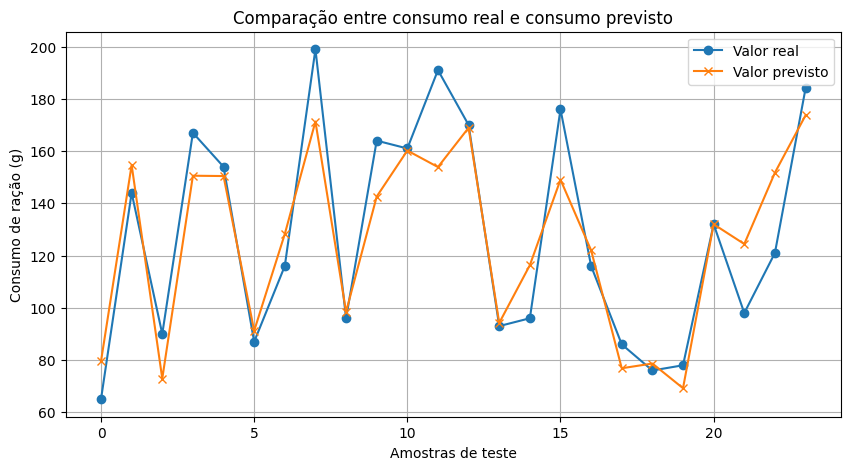

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Valor real", marker="o")
plt.plot(previsoes, label="Valor previsto", marker="x")
plt.title("Comparação entre consumo real e consumo previsto")
plt.xlabel("Amostras de teste")
plt.ylabel("Consumo de ração (g)")
plt.legend()
plt.grid(True)
plt.show()